In [1]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt 
import ast


def result_show_graph(result, ad_str):
    rstr = result
    rdict = ast.literal_eval(rstr)
    ad_list=json.loads(ad_str)
    ad = pd.DataFrame(ad_list)
    G = nx.from_pandas_adjacency(ad)
    m = G.size()
    n = G.order()
            
    i_m = nx.incidence_matrix(G).toarray()
    #edge_number : (vertex1, vertex2)
    edict = {}
    e_m = np.transpose(i_m)
    for ii in range(m):
        edict[ii] = []
        for jj in range(n):
            if e_m[ii][jj] == 1:
                edict[ii].append(jj)
                
    #vertex_number : vertex_label            
    vdict={}
    for i in range(n):
        vdict[i] = 0
        
    #(vertex1,vertex2) : edge_label
    weights = {}
    for i in range(m):
        weights[tuple(edict[i])] = 0
    
    for v, b in rdict.items():
        if v[0] == 'y'and b == 1:
            edge = tuple(edict[int(v[1])])
            w = 2**(int(v[2])) + 1
            weights[edge] += w
            vdict[edge[0]] += w
            vdict[edge[1]] += w
             
    options = {
        "font_size": 20,
        "node_size": 1500,
        "node_color": "white",
        "edgecolors": "black",
        "linewidths": 3,
        "width": 3,
    }
    
    pos = nx.spring_layout(G,seed=2)
    center_node = 0
    nx.set_edge_attributes(G, values = weights, name = 'weight')
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw( G,pos,labels=vdict,**options,with_labels = True)
    nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
    plt.show()

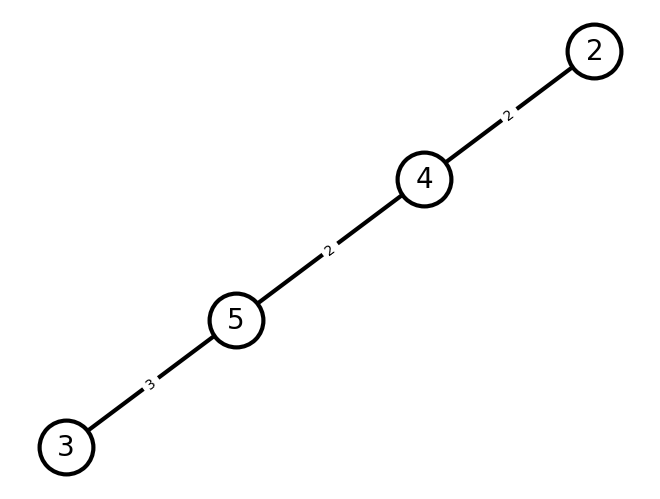

In [3]:
df = pd.read_csv('Advantage2_Prototype_Zephyr/apg4_zephyr.csv')
df2 = pd.read_csv('apgs/base_apgs/apg4_base.csv')
i = 0
result_show_graph(df['sample_3000_20'][i], df2['Adjacency_list'][i])